# 1D Overdamped Oscillator with Physics-Informed Neural Networks

This notebook demonstrates how to solve the **damped harmonic oscillator** equation using Physics-Informed Neural Networks (PINNs). The damped harmonic oscillator is governed by the second-order differential equation:

$$\frac{d^2x}{dt^2} + \beta \frac{dx}{dt} + \omega x = 0$$

where:
- $\omega$ is the angular frequency squared
- $\beta$ is the damping coefficient
- $x(t)$ is the displacement

We will solve this problem using two approaches:
1. **Standard PINN**: A single neural network trained on the entire domain
2. **FBPINN (Finite Basis PINN)**: A domain decomposition approach using multiple smaller networks

In [1]:
import pinns
pinns.use_backend('jax')  # or 'torch'
# pinns.use_backend('torch')  # or 'torch'
import numpy as np
import matplotlib.pyplot as plt

pinns: Using jax backend


# Define the Problem

In this section, we set up all the components needed to define our PINN problem:
1. Physical parameters of the oscillator
2. The differential equation (residual form)
3. The computational domain
4. Initial and boundary conditions

## Parameters of the Model

We define the physical parameters for our oscillator system:
- **beta ($\beta$)**: Damping coefficient (0.1) - controls how quickly oscillations decay
- **omega ($\omega$)**: Angular frequency squared (10) - determines the natural frequency
- **x0**: Initial positions for the oscillator
- **t_max**: Time of simulation

With $\beta = 0.1$ and $\omega = 10$, we have $\omega > \beta^2/4$, which corresponds to the **underdamped** regime where the system oscillates while decaying.

The parameters **x0** and **t_max** is not actually a parameter but the initial condition and the simulation time. We just set them in here as it will send them to the analytic solution to compare.

In [2]:
beta = .1
omega = 10
x0 = 1
t_max = 10

## Domain of the Problem

We need to create the domain of the problem.

The basic cubic domain domain requires:
- **xmin**: list of the minimum limits in each input dimension.
- **xmin**: list of the maximum limits in each input dimension.
- **sampling_method**: how to generate points for the problem. By default `uniform` sampling.
- **sampling_transform**: an auxiliar function that transforms the points from the sampling method to other distribution. e.g. using a `scipy.stats.normal.cdf` to resample points in a gaussian distibution. Transformed points outside the domain are rejected and resampled. This is usefull if you do not want to sample points uniformly in the domain and put more focus in specific regions. By default no transformation is applied.

In our case we just need a 1D domain that describes the time of the simulation and we will keep uniform sampling.

In [3]:
domain = pinns.DomainCubic(
    [0],
    [t_max],
)

## Differential Equation

### The PDE Residual
The `model_overdamped` function computes the residual of the damped oscillator equation. For PINNs, we train the network to minimize this residual:

$$\mathcal{R} = \frac{d^2x}{dt^2} + \beta \frac{dx}{dt} + \omega x = 0$$

The arguments of the function are:

- **X**: Input variables. A pytorch tensor of $N$ by $n_inputs$.
- **U**: Output variables. A pytorch tensor of $N$ by $n_outputs$.
- **params**: A dictionary with the following keys:
    - **params["fixed"]**: The list parameters of the model that will not change or will be infered in inverse problems.
    - **params["dynamic"]**: The list parameters of the model that will be infered in inverse problems. Since this is a forward problem, this will be empty is empty.
    - **params["internal"]**: Internal parameters that can be used during the training as `step` or `global_step`. These parameters can be used for example to do curriculum training of certain stiff models.

Inside the function you can use any torch operations (e.g. `torch.sin`, `torch.sigmoid`....) and algebra.

You can also compute the derivatives using the function `pinns.derivative`. This takes:

- **output_variables**: A tensor containing in a column the variable you want to derive. In our case we can pass simply **Y**.
- **input_variables**: A tensor containing in columns the variables you want to derive with respect to. In our case we can pass simply **X**.
- **variable to derive**: The column containing the variable you want to derive. In our case we just have 1 so position 0.
- **variables to derive**: A tuple containing in order the variables with respect to what derive indicating the column. In our case we **(0,) $\rightarrow \frac{d}{dt}$** **(0,0) $\rightarrow \frac{d^2}{dt^2}$**

The **output** has to be a list with the result of all equations of the model.

In [4]:
# Column convention
# X: t
# Y: x
# For JAX JIT: add 4th argument 'derivative' (optional for PyTorch)
def model_overdamped(X, U, params, derivative=None):
    # Use passed derivative if available, otherwise use default
    if derivative is None:
        derivative = pinns.derivative
    
    # Unpack fixed parameters
    omega = params["fixed"]["omega"]
    beta = params["fixed"]["beta"]

    # Extract the relevant components of Y 
    x = U[:, 0:1] #Unnecessary but makes it more clear
    x_t = derivative(x, X, 0, (0,)) # First derivative with respect to time
    x_tt = derivative(x, X, 0, (0, 0)) # Second derivative with respect to time

    # Compute the residual of the ODE
    res = x_tt + beta * x_t + omega * x

    return res

## Initial/Boundary Conditions

For the oscillator problem, we need to specify **initial conditions** at $t = 0$:

### Dirichlet Conditions (Position)
- $x(0) = x_0 = 1$ for the first oscillator

### Neumann Conditions (Velocity)
- $\frac{dx}{dt}(0) = 0$ (starts at rest)

The Dirichlet and Neumann boundary conditions require:
- **name**: A name for displaying of the boundary.
- **boundary**: A tuple indicating the for each input dimension **0** if lower boundary and **1** if upper boundary.
- **value**: A constant value or a function that takes tensor of sampled **inputs** in the boundary and **parameters** and returns a tensor with just one column.
- **component**: The position of the output variable that is affected.
- **subdomain**: (optional) A range to limit the sampling of that boundary to that region.
- **sampling_method**: (optional) As for the domain but for the boundary.
- **sampling_transform**: (optional) As for the domain but for the baoundary. Default None.

In [5]:
domain.add_dirichlet(
    boundary=(0,),
    value=x0,
    component=0,
    name="Ix"
)
domain.add_neumann(
    boundary=(0,),
    value=0.0,
    component=0,
    name="Iv"
)

DomainCubic(xmin=[0.0], xmax=[10.0], n_conditions=2)

### Analytical Solution (Optional)

In this case we know the analitic solution of the problem, we will add it to evaluate the model error. For the underdamped case ($\omega > \beta^2/4$), the analytical solution is:

$$x(t) = x_0 e^{-\frac{\beta t}{2}} \cos\left(\sqrt{\omega - \frac{\beta^2}{4}} \cdot t\right)$$

The function will take the input and params and return a list of solutions for each equation in the same order than in the residuals definition.

In [6]:
def model_underdamped_analytic(X, params):
    omega = params["fixed"]["omega"]
    beta = params["fixed"]["beta"]
    x0 = params["fixed"]["x0"]

    t = X[:, 0:1]

    return x0 * np.exp(-beta * t / 2) * np.cos(np.sqrt(omega - (beta**2) / 4) * t)

## Assemble the Problem

The `Problem` class combines all components:
- **domain**: Where to sample collocation points
- **model**: The PDE residual function
- **params**: Physical parameters passed to the model
- **n_outputs**: Number of output variables (2: x and y)
- **output_range**: Expected range of outputs (used for unnormalization). We always want that the domain and range of the NN is in the order of 1. Since we know that the maximum range is the initial position in this case, we set the output range to this value so at the end of the network we unnormalize to this scale, allowing the network to give output values between -1 and 1.
- **solution**: Analytical solution for comparison/validation

In [7]:
problem = pinns.Problem(
    domain,
    model_overdamped,
    input_names=["t"],
    output_names=["x"],
    params={"omega": omega, "beta": beta, "x0": x0},
    output_range=[(-x0, x0)],
    solution=model_underdamped_analytic
)

problem.show_problem();

<IPython.core.display.Math object>

# Solve with Standard PINN

## Network Architecture

We use a **Fully Connected Neural Network (FNN)** with:
- **Architecture**: [2, 126, 126, 126, 2] - 2 inputs, three hidden layers with 126 neurons each, 2 outputs
- **Activation**: `tanh` - smooth activation suitable for learning smooth physical solutions
- **normalize_input**: `False` - inputs are not normalized
- **unnormalize_output**: `True` - outputs are denormalized using the specified output range

In [8]:
network = pinns.FNN([1, 126, 126, 126, 1], activation="tanh", normalize_input=True, unnormalize_output=True)

## Training Configuration

The trainer is configured with:
- **train_samples**: [1000, 100, 100, 100, 100] - samples for PDE residual and each boundary condition
- **test_samples**: [1000, 0, 0, 0, 0] - samples for testing (only PDE residual)
- **weights**: Equal weighting (1.0) for all loss terms
- **optimizer**: Adam with learning rate $10^{-3}$
- **epochs**: 10,000 training iterations
- **print_each**: Print progress every 500 epochs

Starting training for 10000 epochs (JIT-compiled)...


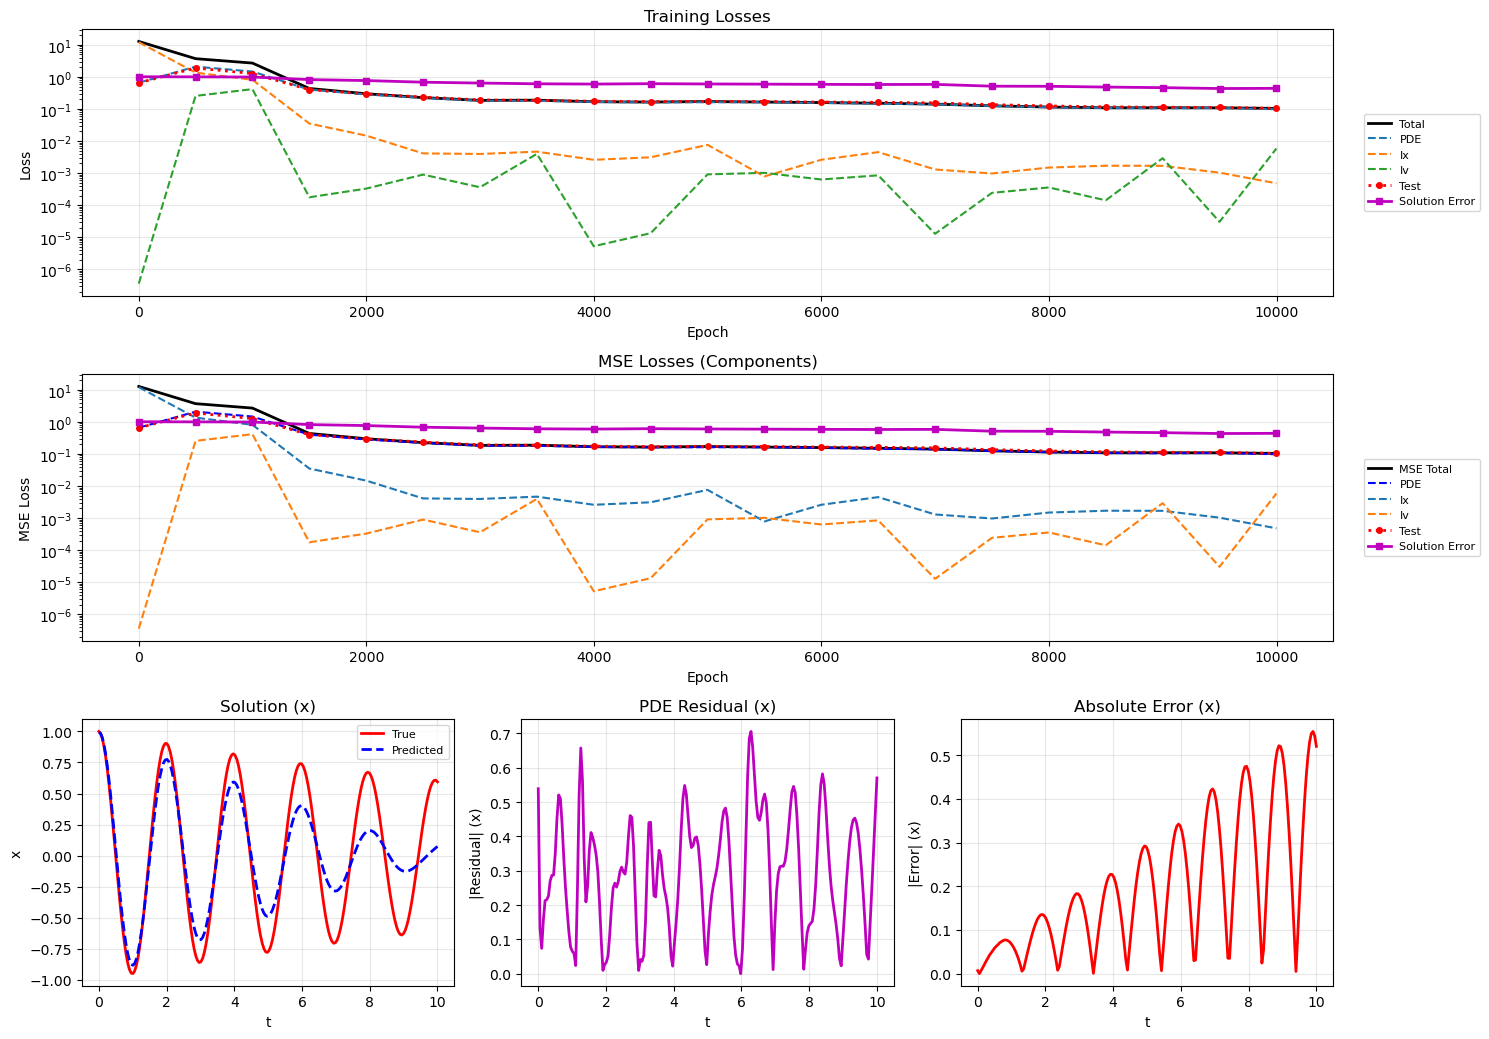

Epoch 0/10000 | Loss: 1.27e+01 | MSE Loss: 1.27e+01 | PDE: 6.58e-01 | BCs: [Ix: 1.21e+01, Iv: 3.60e-07] | Time: 0.0s | Test Loss: 6.51e-01 | Error: 1.01e+00
Epoch 500/10000 | Loss: 3.70e+00 | MSE Loss: 3.70e+00 | PDE: 2.09e+00 | BCs: [Ix: 1.36e+00, Iv: 2.56e-01] | Time: 5.3s | Test Loss: 1.90e+00 | Error: 1.00e+00
Epoch 1000/10000 | Loss: 2.69e+00 | MSE Loss: 2.69e+00 | PDE: 1.47e+00 | BCs: [Ix: 8.12e-01, Iv: 4.15e-01] | Time: 6.0s | Test Loss: 1.27e+00 | Error: 9.91e-01
Epoch 1500/10000 | Loss: 4.36e-01 | MSE Loss: 4.36e-01 | PDE: 4.01e-01 | BCs: [Ix: 3.51e-02, Iv: 1.77e-04] | Time: 6.8s | Test Loss: 3.99e-01 | Error: 8.23e-01
Epoch 2000/10000 | Loss: 2.98e-01 | MSE Loss: 2.98e-01 | PDE: 2.83e-01 | BCs: [Ix: 1.48e-02, Iv: 3.29e-04] | Time: 7.5s | Test Loss: 2.95e-01 | Error: 7.68e-01
Epoch 2500/10000 | Loss: 2.26e-01 | MSE Loss: 2.26e-01 | PDE: 2.21e-01 | BCs: [Ix: 4.12e-03, Iv: 9.00e-04] | Time: 8.2s | Test Loss: 2.36e-01 | Error: 6.83e-01
Epoch 3000/10000 | Loss: 1.85e-01 | MSE Loss

In [ ]:
trainer = pinns.Trainer(
    problem,
    network,
)

trainer.compile(
    train_samples = {
        "pde": 1000,
        "Ix": 1,
        "Iv": 1,
    },
    test_samples = {
        "pde": 1000,
        "Ix": 0,
        "Iv": 0,
    },
    weights={
        "pde": 1.0,
        "Ix": 1.0,
        "Iv": 1.0,
    },
    optimizer="adam",
    learning_rate=1e-3,
    epochs=10000,
    print_each=500,
    show_plots=True,
)

trainer.train()

# Solve with FBPINN (Finite Basis PINN)

**FBPINN** is a domain decomposition approach that addresses limitations of standard PINNs for problems with:
- Multiple frequency scales
- Long time evolution
- Complex domains

Instead of a single large network, FBPINN uses **multiple smaller networks** on overlapping subdomains. This allows:
- Better local approximation
- Parallel training potential
- Improved handling of oscillatory solutions

For using them we will need to generated a partitioned domain and see the overlap.

## Domain Partition

We divide the domain into a grid of subdomains:
- **Time dimension**: 10 subdivisions from 0 to t. This partitions can be adapted and made irregular depending on the conditions.
- **Overlap**: The overlap between subdomains. More overlapping give smoother solutions between adjacent subdomains. We will put 50% overlap.

In [10]:
domain_partition = pinns.DomainCubicPartition(
    [np.linspace(0,t_max,10)],
    overlap=0.5
)

Because we have generated a new domain and the boundary conditions and problem depend on the domain, we need to reassign them again.

In [11]:
domain_partition.add_dirichlet(
    boundary=(0,),
    value=x0,
    component=0,
    name="initial_position"
)
domain_partition.add_neumann(
    boundary=(0,),
    value=0.0,
    component=0,
    name="initial_velocity"
)

DomainCubicPartition(xmin=[0.0], xmax=[10.0], n_subdomains_per_dim=[9], total_subdomains=9, n_conditions=2)

In [12]:
problem = pinns.Problem(
    domain_partition,
    model_overdamped,
    input_names=["t"],
    output_names=["x"],
    params={"omega": omega, "beta": beta, "x0": x0},
    output_range=[(-x0, x0)],
    solution=model_underdamped_analytic
)

problem.show_problem()

<IPython.core.display.Math object>

'\\min_\\theta\\; \\mathcal{L}(\\theta)=\\frac{w_{x}}{N_{x}}\\left\\|\\mathcal{R}_{x}\\right\\|_2^2 + \\frac{w_{initial\\_position}}{N_{initial\\_position}}\\left\\|\\mathcal{B}_{initial\\_position}\\right\\|_2^2 + \\frac{w_{initial\\_velocity}}{N_{initial\\_velocity}}\\left\\|\\mathcal{B}_{initial\\_velocity}\\right\\|_2^2 \\\\[4pt] \\begin{array}{l} \\mathcal{R}_{x}:\\text{ PDE residual for }x \\\\ N_{x}:\\text{ number of PDE samples for }x \\\\ w_{x}:\\text{ weight for }x \\\\ \\mathcal{B}_{initial\\_position}:\\text{ Dirichlet residual for }initial\\_position \\\\ N_{initial\\_position}:\\text{ number of samples for }initial\\_position \\\\ w_{initial\\_position}:\\text{ weight for }initial\\_position \\\\ \\mathcal{B}_{initial\\_velocity}:\\text{ Neumann residual for }initial\\_velocity \\\\ N_{initial\\_velocity}:\\text{ number of samples for }initial\\_velocity \\\\ w_{initial\\_velocity}:\\text{ weight for }initial\\_velocity \\end{array}'

## FBPINN Network Architecture

We create:
1. A **base network**: Smaller FNN [2, 32, 2] that will be replicated across subdomains
2. The **FBPINN wrapper**: Manages the ensemble of networks and their window functions

Each subdomain gets its own copy of the base network, with smooth window functions ensuring continuity at subdomain boundaries.

In [13]:
baseNetwork = pinns.FNN([1, 32, 1], activation="tanh")

network = pinns.FBPINN(
    domain_partition,
    baseNetwork,
    normalize_input=True,
    unnormalize_output=True,
)

## FBPINN Training

Now we train again this network. We see that the network converges to the solution in less than half of the time and with smaller networks.

Starting training for 10000 epochs (JIT-compiled)...


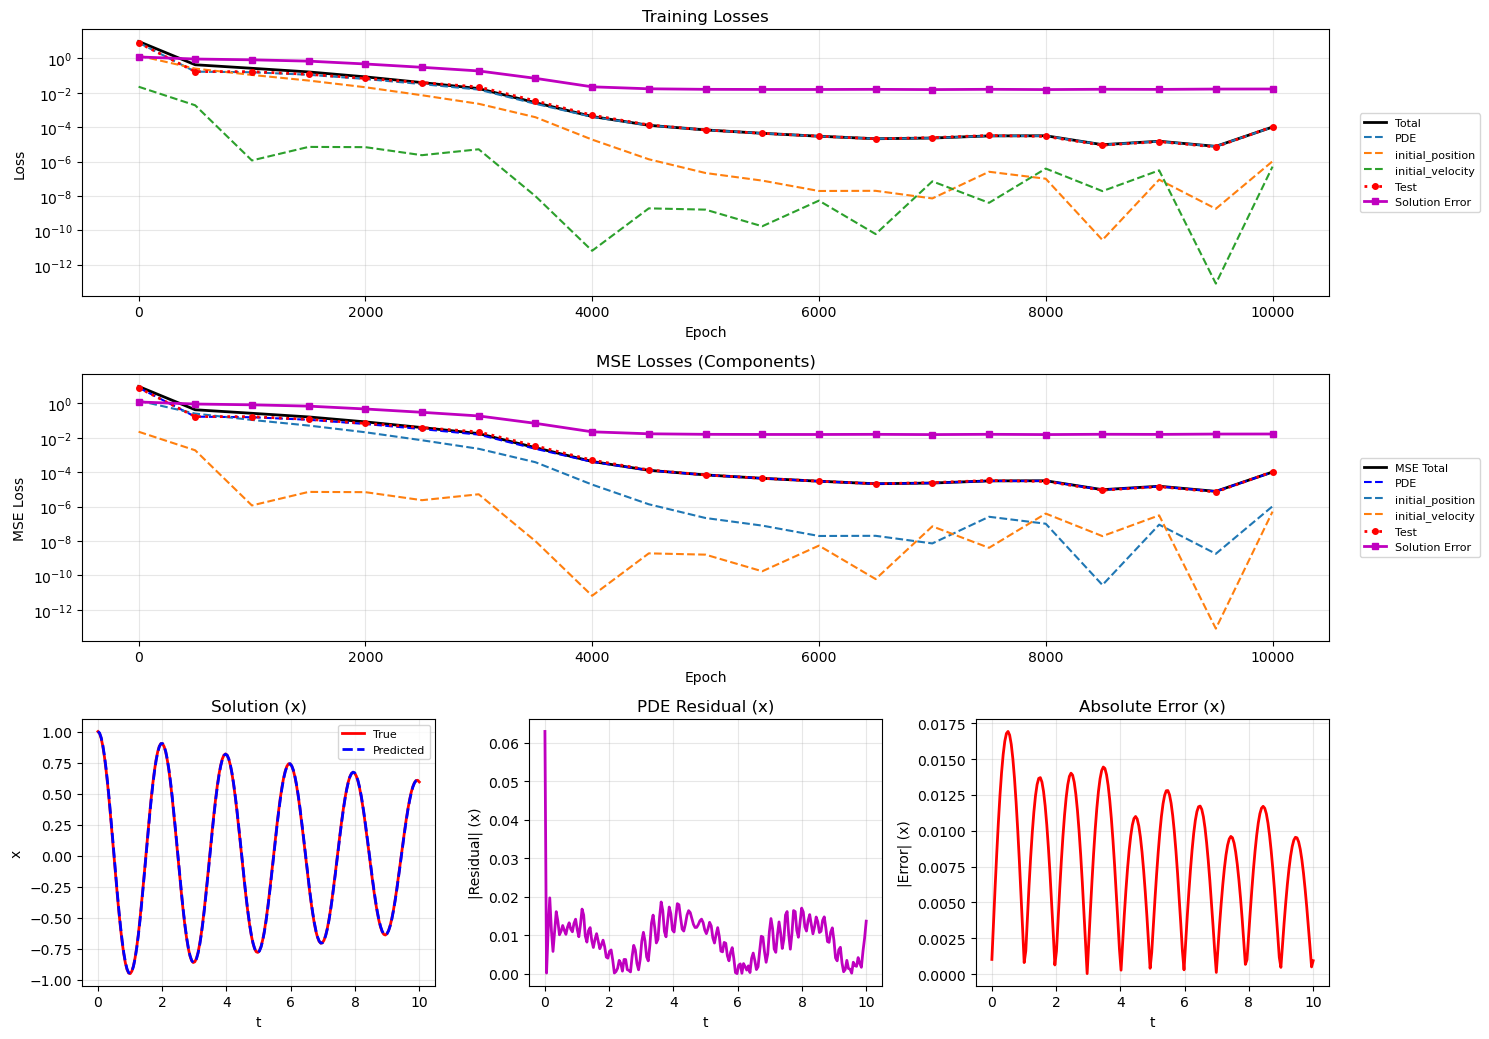

Epoch 0/10000 | Loss: 9.68e+00 | MSE Loss: 9.68e+00 | PDE: 8.22e+00 | BCs: [initial_position: 1.44e+00, initial_velocity: 2.25e-02] | Time: 0.0s | Test Loss: 8.07e+00 | Error: 1.21e+00
Epoch 500/10000 | Loss: 4.27e-01 | MSE Loss: 4.27e-01 | PDE: 1.69e-01 | BCs: [initial_position: 2.56e-01, initial_velocity: 1.87e-03] | Time: 6.3s | Test Loss: 1.70e-01 | Error: 9.20e-01
Epoch 1000/10000 | Loss: 2.66e-01 | MSE Loss: 2.66e-01 | PDE: 1.57e-01 | BCs: [initial_position: 1.09e-01, initial_velocity: 1.17e-06] | Time: 7.1s | Test Loss: 1.70e-01 | Error: 8.27e-01
Epoch 1500/10000 | Loss: 1.63e-01 | MSE Loss: 1.63e-01 | PDE: 1.12e-01 | BCs: [initial_position: 5.15e-02, initial_velocity: 7.13e-06] | Time: 7.8s | Test Loss: 1.19e-01 | Error: 6.93e-01
Epoch 2000/10000 | Loss: 8.44e-02 | MSE Loss: 8.44e-02 | PDE: 6.34e-02 | BCs: [initial_position: 2.10e-02, initial_velocity: 6.91e-06] | Time: 8.6s | Test Loss: 6.87e-02 | Error: 4.74e-01
Epoch 2500/10000 | Loss: 3.92e-02 | MSE Loss: 3.92e-02 | PDE: 3.

In [14]:
trainer = pinns.Trainer(
    problem,
    network,
)

trainer.compile(
    train_samples = {
        "pde": 1000,
        "initial_position": 1,
        "initial_velocity": 1,
    },
    test_samples = {
        "pde": 1000,
        "initial_position": 0,
        "initial_velocity": 0,
    },
    weights={
        "pde": 1.0,
        "initial_position": 1.0,
        "initial_velocity": 1.0,
    },
    optimizer="adam",
    learning_rate=1e-3,
    epochs=10000,
    print_each=500,
    show_plots=True,
)

trainer.train()

# Solve with ALPINN
## Problem

In [15]:
problem = pinns.Problem(
    domain_partition,
    model_overdamped,
    input_names=["t"],
    output_names=["x"],
    params={"omega": omega, "beta": beta, "x0": x0},
    lagrange_multipliers=["Ip", "Iv"],
    output_range=[(-x0, x0)],
    solution=model_underdamped_analytic
)

problem.show_problem()

<IPython.core.display.Math object>

'\\min_\\theta\\; \\mathcal{L}(\\theta)=\\frac{w_{x}}{N_{x}}\\left\\|\\mathcal{R}_{x}\\right\\|_2^2 + \\frac{w_{initial\\_position}}{N_{initial\\_position}}\\left\\|\\mathcal{B}_{initial\\_position}\\right\\|_2^2 + \\frac{w_{initial\\_velocity}}{N_{initial\\_velocity}}\\left\\|\\mathcal{B}_{initial\\_velocity}\\right\\|_2^2 \\\\[4pt] \\begin{array}{l} \\mathcal{R}_{x}:\\text{ PDE residual for }x \\\\ N_{x}:\\text{ number of PDE samples for }x \\\\ w_{x}:\\text{ weight for }x \\\\ \\mathcal{B}_{initial\\_position}:\\text{ Dirichlet residual for }initial\\_position \\\\ N_{initial\\_position}:\\text{ number of samples for }initial\\_position \\\\ w_{initial\\_position}:\\text{ weight for }initial\\_position \\\\ \\mathcal{B}_{initial\\_velocity}:\\text{ Neumann residual for }initial\\_velocity \\\\ N_{initial\\_velocity}:\\text{ number of samples for }initial\\_velocity \\\\ w_{initial\\_velocity}:\\text{ weight for }initial\\_velocity \\end{array}'



We use a **Fully Connected Neural Network (FNN)** with:
- **Architecture**: [2, 126, 126, 126, 2] - 2 inputs, three hidden layers with 126 neurons each, 2 outputs
- **Activation**: `tanh` - smooth activation suitable for learning smooth physical solutions
- **normalize_input**: `False` - inputs are not normalized
- **unnormalize_output**: `True` - outputs are denormalized using the specified output range

In [19]:
network = pinns.FNN([1, 126, 126, 126, 1], activation="tanh")

In [20]:
trainer = pinns.Trainer(
    problem,
    network,
)

## Training Configuration

The trainer is configured with:
- **train_samples**: [1000, 100, 100, 100, 100] - samples for PDE residual and each boundary condition
- **test_samples**: [1000, 0, 0, 0, 0] - samples for testing (only PDE residual)
- **weights**: Equal weighting (1.0) for all loss terms
- **optimizer**: Adam with learning rate $10^{-3}$
- **epochs**: 10,000 training iterations
- **print_each**: Print progress every 500 epochs

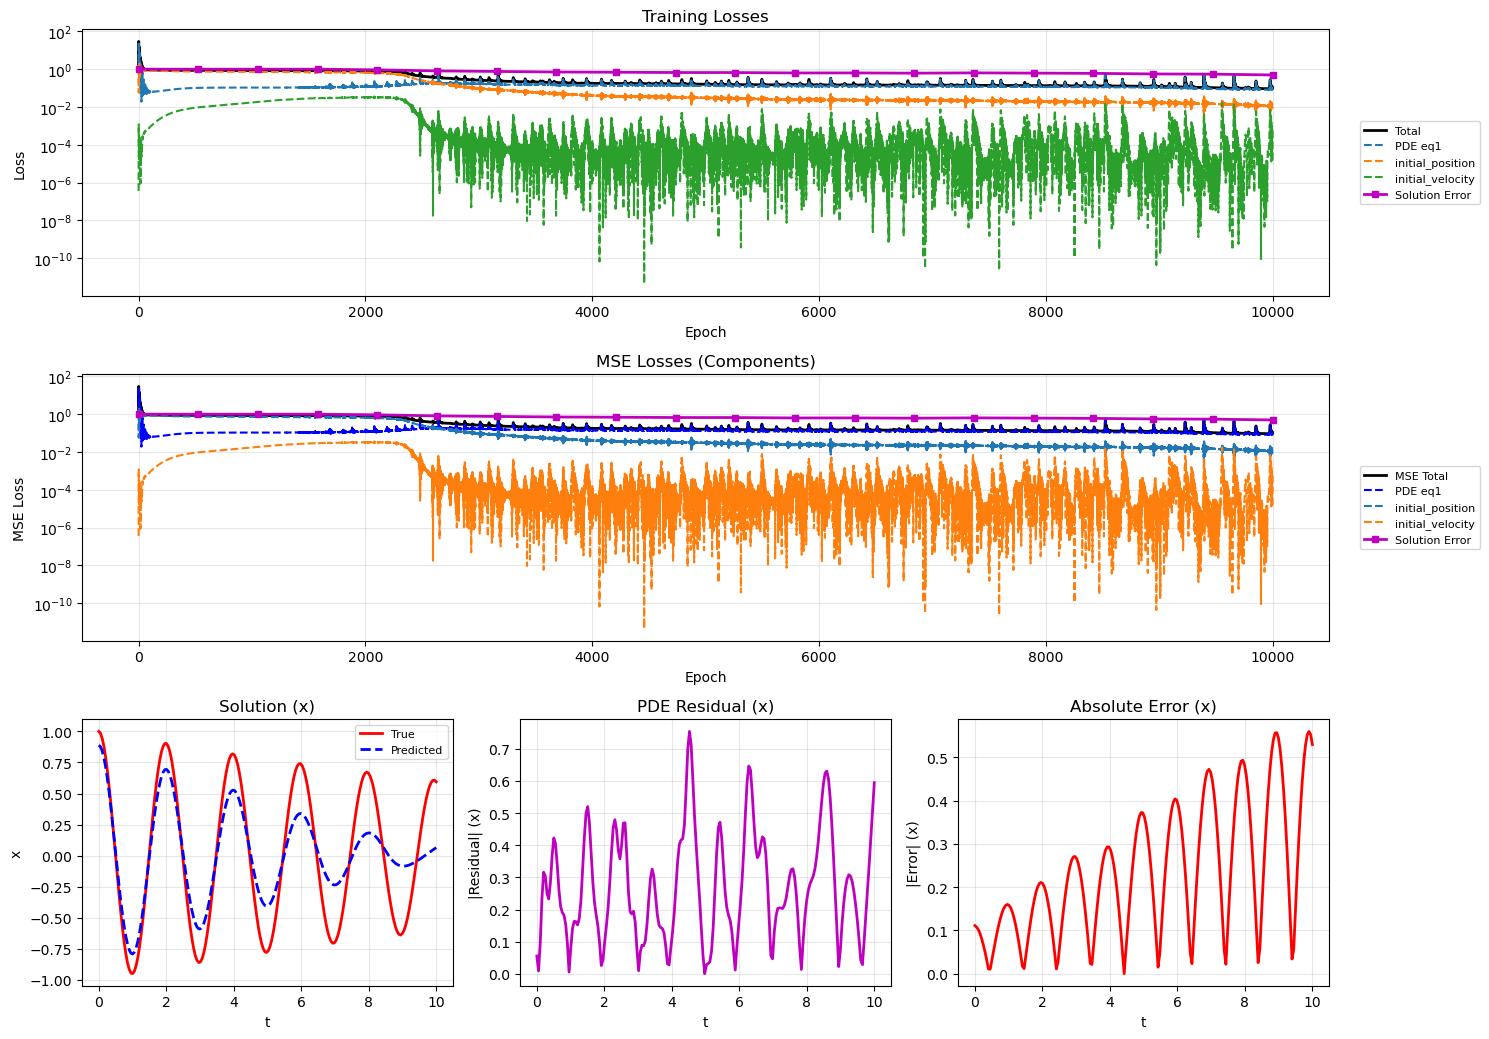

Starting Trainer (JAX, Lagrangian mode) for 10000 epochs...
Epoch 500/10000 | AL Loss: 8.60e-01 | MSE Loss: 8.60e-01 | PDE: 1.02e-01 | BCs: [initial_position: 7.49e-01, initial_velocity: 9.13e-03] | Time: 1.8s | Error: 1.00e+00
Epoch 1000/10000 | AL Loss: 8.43e-01 | MSE Loss: 8.43e-01 | PDE: 1.06e-01 | BCs: [initial_position: 7.19e-01, initial_velocity: 1.76e-02] | Time: 3.0s | Error: 9.97e-01
Epoch 1500/10000 | AL Loss: 8.28e-01 | MSE Loss: 8.28e-01 | PDE: 1.06e-01 | BCs: [initial_position: 6.94e-01, initial_velocity: 2.83e-02] | Time: 4.1s | Error: 9.96e-01
Epoch 2000/10000 | AL Loss: 8.19e-01 | MSE Loss: 8.19e-01 | PDE: 1.33e-01 | BCs: [initial_position: 6.55e-01, initial_velocity: 3.14e-02] | Time: 5.1s | Error: 1.00e+00
Epoch 2500/10000 | AL Loss: 4.40e-01 | MSE Loss: 4.40e-01 | PDE: 1.85e-01 | BCs: [initial_position: 2.51e-01, initial_velocity: 3.38e-03] | Time: 6.2s | Error: 9.24e-01
Epoch 3000/10000 | AL Loss: 2.62e-01 | MSE Loss: 2.62e-01 | PDE: 1.62e-01 | BCs: [initial_positi

In [23]:
trainer = pinns.Trainer(
    problem,
    network,
)

trainer.compile(
    train_samples = {
        "pde": 1000,
        "initial_position": 1,
        "initial_velocity": 1,
    },
    test_samples = {
        "pde": 1000,
        "initial_position": 0,
        "initial_velocity": 0,
    },
    weights={
        "pde": 1.0,
        "initial_position": 1.0,
        "initial_velocity": 1.0,
    },
    optimizer="adam",
    learning_rate=1e-3,
    lagrange_optimizer='adam',
    lagrange_lr=1e-4,
    epochs=10000,
    print_each=500,
    show_plots=True,
)

trainer.train()